In [46]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import numpy as np
import ast

# Global style configuration
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [47]:
results_dir = 'results_sim'

# Load the log files
df_ga = pd.read_csv(f'{results_dir}/ga_log.csv')
df_batch = pd.read_csv(f'{results_dir}/log_batch.csv')
df_items = pd.read_csv(f'{results_dir}/log_items_delivered.csv')

# Preprocessing item data (converting to hours)
df_items['Arrival Time (hr)'] = df_items['arrival_time'] / 60.0
df_items['Delivery Time (hr)'] = df_items['sim_time_delivery'] / 60.0
df_items['TCT (hr)'] = df_items['tct'] / 60.0

# Add priority labels
priority_map = {1.0: 'P1 (Urgent)', 2.0: 'P2 (Standard)', 3.0: 'P3 (Low)'}
df_items['Priority_label'] = df_items['priority'].map(priority_map)

# Preprocessing batch and robot battery data
df_batch['sim_time_end_hr'] = df_batch['sim_time_end'] / 60.0
df_batch['robot_0_battery'] = df_batch['robot_batteries'].apply(
    lambda x: ast.literal_eval(x)[0] if pd.notnull(x) else np.nan
)
df_batch['robot_0_battery_hr'] = df_batch['robot_0_battery'] / 60.0

# Preprocessing cumulative backlog statistics
arrival_times_hr = df_items['Arrival Time (hr)'].values
delivery_times_hr = df_items['Delivery Time (hr)'].values

# Create a unified timeline of unique events
unique_timeline_hr = np.unique(np.concatenate([[0.0], arrival_times_hr, delivery_times_hr]))
unique_timeline_hr = np.sort(unique_timeline_hr)

backlog_data = []
for t in unique_timeline_hr:
    arrivals_up_to_t = np.searchsorted(np.sort(arrival_times_hr), t, side='right')
    deliveries_up_to_t = np.searchsorted(np.sort(delivery_times_hr), t, side='right')
    
    backlog_data.append({
        'sim_time_hr': t,
        'cumulative_arrivals': arrivals_up_to_t,
        'cumulative_deliveries': deliveries_up_to_t,
        'available_for_delivery': arrivals_up_to_t - deliveries_up_to_t
    })
df_backlog = pd.DataFrame(backlog_data)

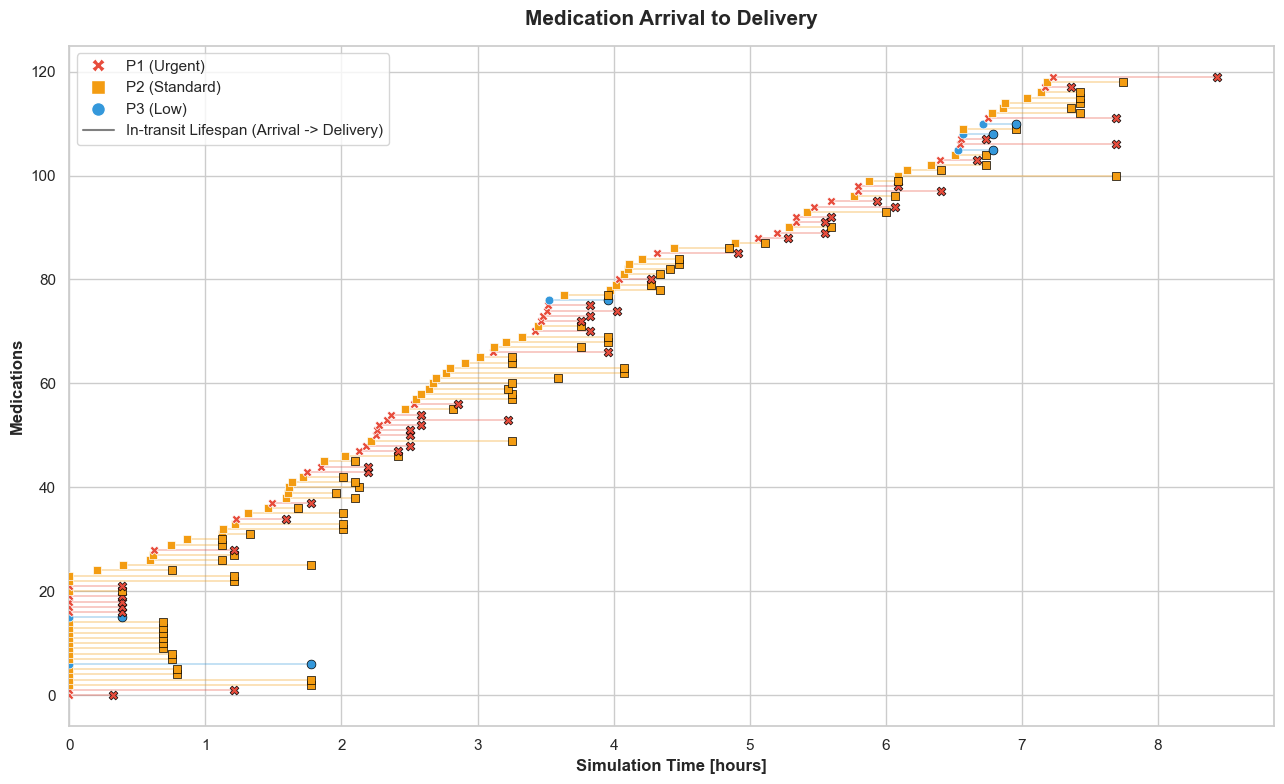

In [48]:
fig1, ax1 = plt.subplots(figsize=(13, 8))

# Sort to create a sequential flow layout
df_items_sorted = df_items.sort_values('Arrival Time (hr)').reset_index(drop=True)
df_items_sorted['Plot_Y'] = df_items_sorted.index

colours = {'P1 (Urgent)': '#e74c3c', 'P2 (Standard)': '#f39c12', 'P3 (Low)': '#3498db'}
markers = {'P1 (Urgent)': 'X', 'P2 (Standard)': 's', 'P3 (Low)': 'o'}

for idx, row in df_items_sorted.iterrows():
    p_label = row['Priority_label']
    c = colours.get(p_label, 'black')
    m = markers.get(p_label, 'o')
    
    # Lifespan duration line
    ax1.plot([row['Arrival Time (hr)'], row['Delivery Time (hr)']], [row['Plot_Y'], row['Plot_Y']], 
             color=c, alpha=0.35, linewidth=1.2)
    # Arrival point
    ax1.scatter(row['Arrival Time (hr)'], row['Plot_Y'], color=c, marker=m, s=40, edgecolors='white', linewidths=0.5, zorder=4)
    # Delivery point
    ax1.scatter(row['Delivery Time (hr)'], row['Plot_Y'], color=c, marker=m, s=40, edgecolors='black', linewidths=0.5, zorder=5)

ax1.set_title('Medication Arrival to Delivery', fontsize=15, fontweight='bold', pad=15)
ax1.set_xlabel('Simulation Time [hours]', fontsize=12, fontweight='bold')
ax1.set_ylabel('Medications', fontsize=12, fontweight='bold')
ax1.set_xlim(left=0)

# Custom legend mapping
legend_elements = [
    mlines.Line2D([0], [0], marker='X', color='w', markerfacecolor='#e74c3c', markersize=10, label='P1 (Urgent)'),
    mlines.Line2D([0], [0], marker='s', color='w', markerfacecolor='#f39c12', markersize=10, label='P2 (Standard)'),
    mlines.Line2D([0], [0], marker='o', color='w', markerfacecolor='#3498db', markersize=10, label='P3 (Low)'),
    mlines.Line2D([0], [0], color='gray', linestyle='-', linewidth=1.5, label='In-transit Lifespan (Arrival -> Delivery)')
]
ax1.legend(handles=legend_elements, loc='upper left', frameon=True)
plt.tight_layout()
plt.show()

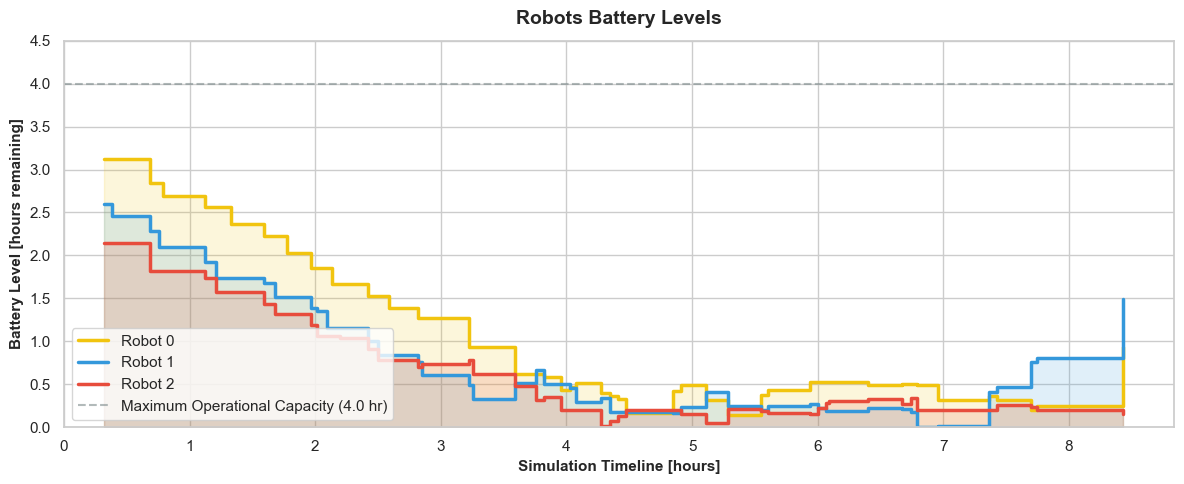

In [49]:
import ast

fig2, ax_bat = plt.subplots(figsize=(12, 5))

# 1. Converter a string "[...]" para uma lista real de Python
if 'robot_batteries_list' not in df_batch.columns:
    df_batch['robot_batteries_list'] = df_batch['robot_batteries'].apply(ast.literal_eval)

# Descobrir o número de robôs a partir da primeira linha
num_robots = len(df_batch['robot_batteries_list'].iloc[0])

# Cores para diferenciar até 5 robôs (pode adicionar mais se necessário)
colors = ['#f1c40f', '#3498db', '#e74c3c', '#2ecc71', '#9b59b6']

# 2. Iterar e plotar dinamicamente cada robô
for i in range(num_robots):
    # Extrair a bateria do robô i e converter para horas ( / 60.0 )
    robot_bat_hr = df_batch['robot_batteries_list'].apply(lambda x: x[i] / 60.0)
    cor = colors[i % len(colors)]
    
    # Step plot
    ax_bat.step(df_batch['sim_time_end_hr'], robot_bat_hr, where='post', color=cor, linewidth=2.5, label=f'Robot {i}')
    ax_bat.fill_between(df_batch['sim_time_end_hr'], robot_bat_hr, step="post", alpha=0.15, color=cor)

# Reference line for maximum capacity
ax_bat.axhline(y=4.0, color='#7f8c8d', linestyle='--', alpha=0.6, label='Maximum Operational Capacity (4.0 hr)')

ax_bat.set_title('Robots Battery Levels', fontsize=14, fontweight='bold', pad=12)
ax_bat.set_xlabel('Simulation Timeline [hours]', fontsize=11, fontweight='bold')
ax_bat.set_ylabel('Battery Level [hours remaining]', fontsize=11, fontweight='bold')
ax_bat.set_ylim(0, 4.5)
ax_bat.set_xlim(left=0)
ax_bat.legend(loc='lower left')
plt.tight_layout()
plt.show()

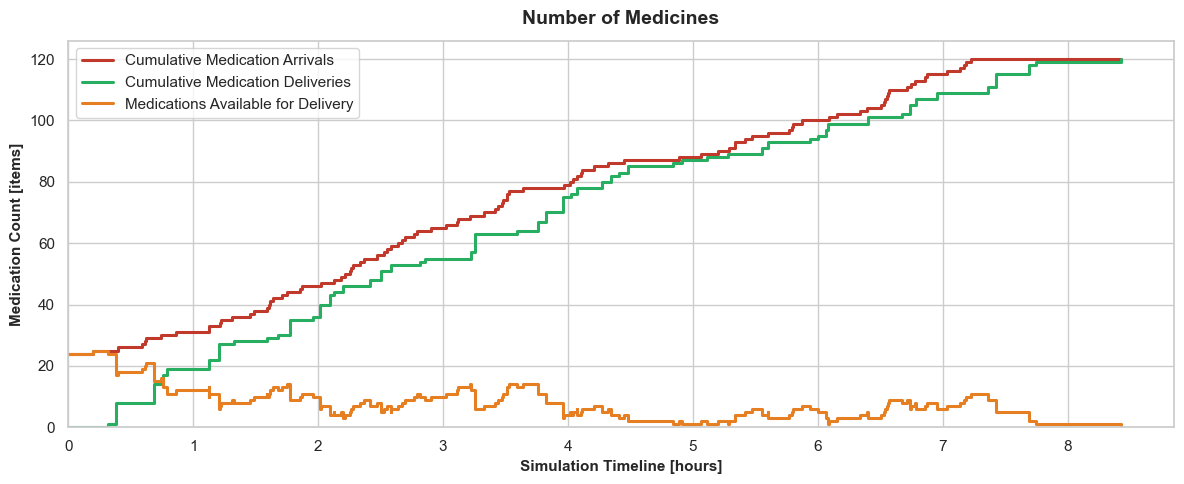

In [50]:
fig3, ax_backlog = plt.subplots(figsize=(12, 5))

# 1. Cumulative Medication Arrivals
ax_backlog.step(df_backlog['sim_time_hr'], df_backlog['cumulative_arrivals'], where='post', label='Cumulative Medication Arrivals', color='#c0392b', linewidth=2.2)

# 2. Cumulative Medication Deliveries
ax_backlog.step(df_backlog['sim_time_hr'], df_backlog['cumulative_deliveries'], where='post', label='Cumulative Medication Deliveries', color='#27ae60', linewidth=2.2)

# 3. Medications Available for Delivery (Active Backlog)
ax_backlog.step(df_backlog['sim_time_hr'], df_backlog['available_for_delivery'], where='post', label='Medications Available for Delivery', color='#e67e22', linewidth=2.2)

ax_backlog.set_title('Number of Medicines', fontsize=14, fontweight='bold', pad=12)
ax_backlog.set_xlabel('Simulation Timeline [hours]', fontsize=11, fontweight='bold')
ax_backlog.set_ylabel('Medication Count [items]', fontsize=11, fontweight='bold')
ax_backlog.set_xlim(left=0)
ax_backlog.set_ylim(bottom=0)
ax_backlog.legend(loc='upper left', frameon=True)

plt.tight_layout()
plt.show()

c:\Users\narig\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\narig\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\narig\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\narig\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_cat

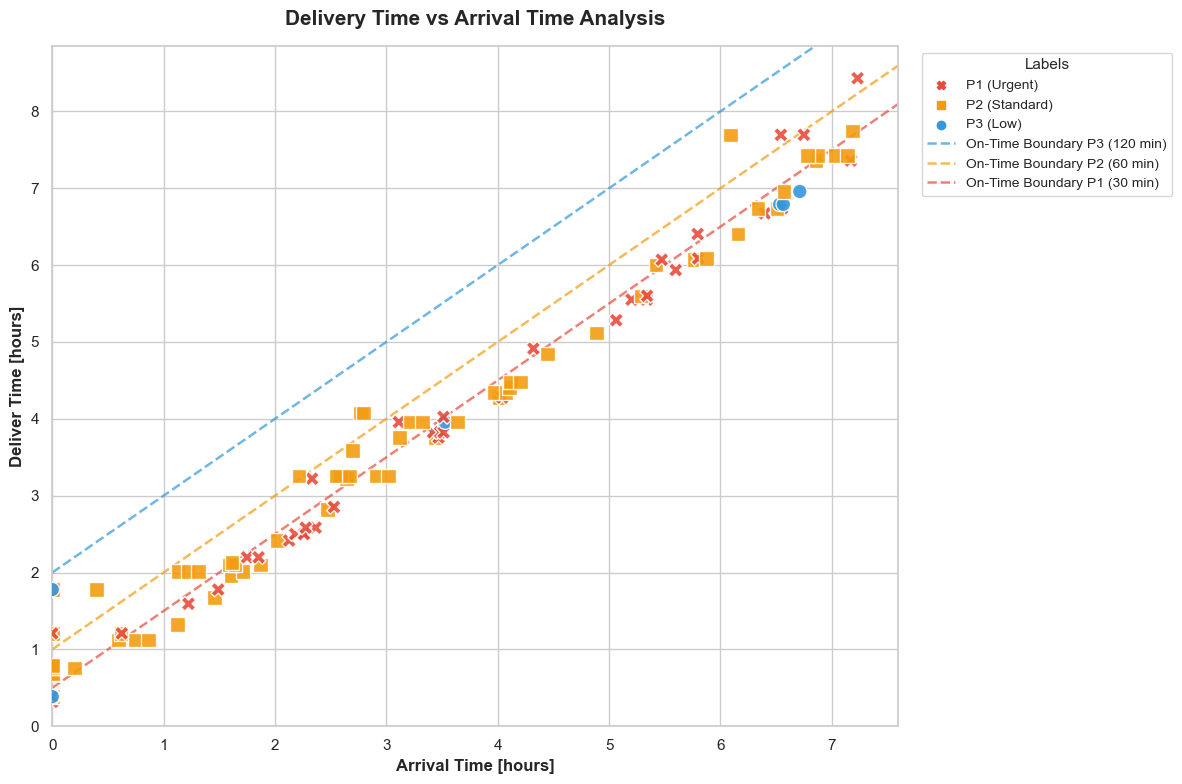

In [51]:
# Garantir que as colunas existem
df_items['Arrival Time (hr)'] = df_items['arrival_time'] / 60.0
df_items['Delivery Time (hr)'] = df_items['sim_time_delivery'] / 60.0

fig4, ax_tct = plt.subplots(figsize=(12, 8))

# Main Scatter: X = Arrival Time, Y = Delivery Time
sns.scatterplot(
    data=df_items,
    x='Arrival Time (hr)',
    y='Delivery Time (hr)', # Alterado para Delivery Time
    hue='Priority_label',
    style='Priority_label',
    markers={'P1 (Urgent)': 'X', 'P2 (Standard)': 's', 'P3 (Low)': 'o'},
    palette={'P1 (Urgent)': '#e74c3c', 'P2 (Standard)': '#f39c12', 'P3 (Low)': '#3498db'},
    s=110, linewidth=1.0, edgecolor='w', alpha=0.9, ax=ax_tct, zorder=5
)

# 1. Definir o intervalo do eixo X (Arrival Time)
max_x = df_items['Arrival Time (hr)'].max()
x_vals = np.array([0, max_x * 1.05])

# 2. Criar as linhas diagonais ( y = x + deadline_em_horas )
# P3: Deadline 120 min = 2.0h
ax_tct.plot(x_vals, x_vals + 2.0, color='#3498db', linestyle='--', linewidth=1.8, alpha=0.7, label='On-Time Boundary P3 (120 min)', zorder=2)

# P2: Deadline 60 min = 1.0h
ax_tct.plot(x_vals, x_vals + 1.0, color='#f39c12', linestyle='--', linewidth=1.8, alpha=0.7, label='On-Time Boundary P2 (60 min)', zorder=2)

# P1: Deadline 30 min = 0.5h
ax_tct.plot(x_vals, x_vals + 0.5, color='#e74c3c', linestyle='--', linewidth=1.8, alpha=0.7, label='On-Time Boundary P1 (30 min)', zorder=2)

# Formatting Titles and Axes
ax_tct.set_title('Delivery Time vs Arrival Time Analysis', fontsize=15, fontweight='bold', pad=15)
ax_tct.set_xlabel('Arrival Time [hours]', fontsize=12, fontweight='bold')
ax_tct.set_ylabel('Deliver Time [hours]', fontsize=12, fontweight='bold')

ax_tct.set_ylim(bottom=0, top=df_items['Delivery Time (hr)'].max() * 1.05)
ax_tct.set_xlim(left=0, right=max_x * 1.05)

ax_tct.legend(title="Labels", title_fontsize='11', fontsize='10', loc='upper left', bbox_to_anchor=(1.02, 1.0), frameon=True)
plt.tight_layout()
plt.show()

c:\Users\narig\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\narig\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\narig\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\narig\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.

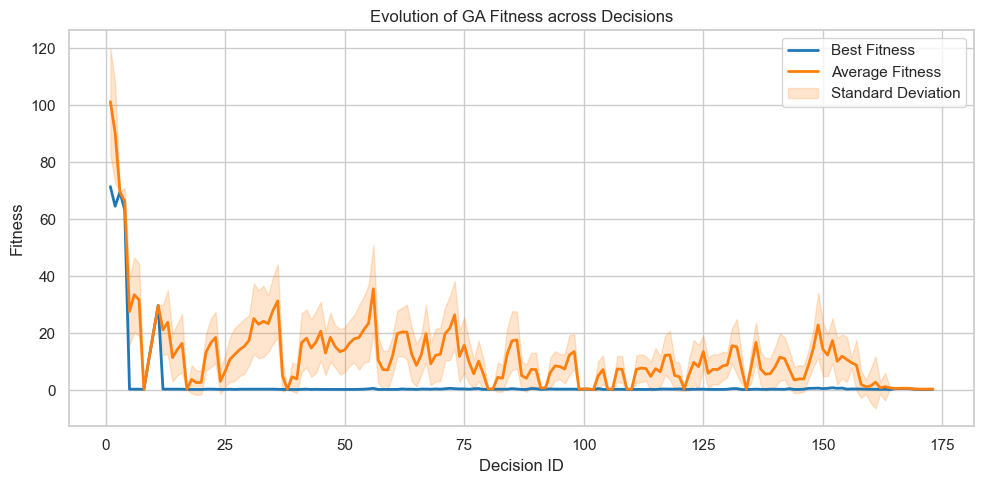

In [52]:
# 6. Evolution of GA Fitness
plt.figure(figsize=(10, 5))
sns.lineplot(data=df_ga, x='decision_id', y='best_fitness', label='Best Fitness', color='#1f77b4', linewidth=2)
sns.lineplot(data=df_ga, x='decision_id', y='avg_fitness', label='Average Fitness', color='#ff7f0e', linewidth=2)
plt.fill_between(df_ga['decision_id'], df_ga['avg_fitness'] - df_ga['std_fitness'], 
                 df_ga['avg_fitness'] + df_ga['std_fitness'], color='#ff7f0e', alpha=0.2, label='Standard Deviation')
plt.title('Evolution of GA Fitness across Decisions')
plt.xlabel('Decision ID')
plt.ylabel('Fitness')
plt.legend()
plt.tight_layout()
plt.show()

c:\Users\narig\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\narig\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\narig\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\narig\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.

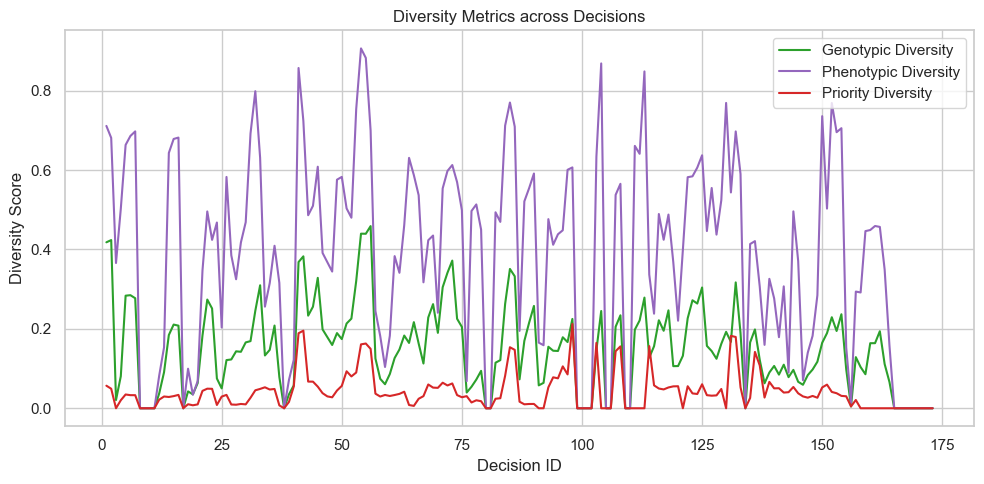

In [53]:
# 7. GA Population Diversity
plt.figure(figsize=(10, 5))
sns.lineplot(data=df_ga, x='decision_id', y='genotypic_diversity', label='Genotypic Diversity', color='#2ca02c')
sns.lineplot(data=df_ga, x='decision_id', y='phenotypic_diversity', label='Phenotypic Diversity', color='#9467bd')
sns.lineplot(data=df_ga, x='decision_id', y='priority_diversity', label='Priority Diversity', color='#d62728')
plt.title('Diversity Metrics across Decisions')
plt.xlabel('Decision ID')
plt.ylabel('Diversity Score')
plt.legend()
plt.tight_layout()
plt.show()

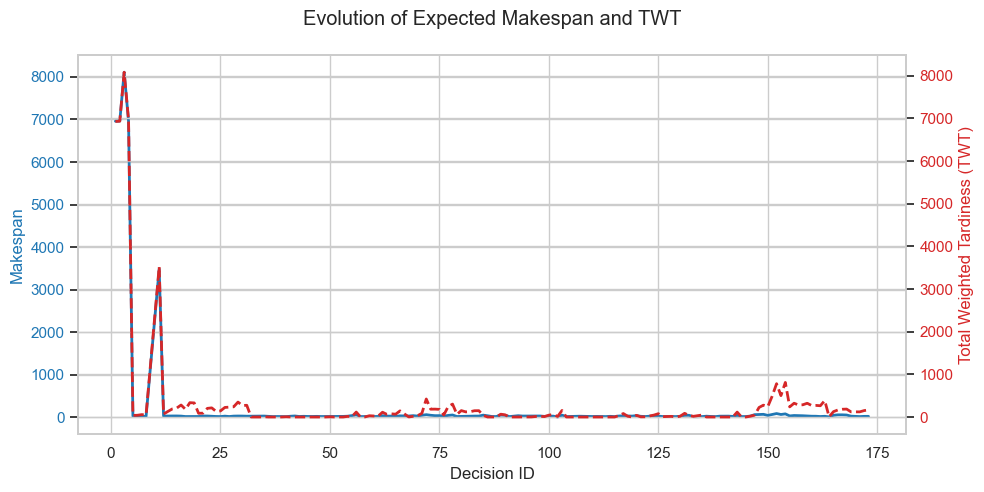

In [54]:
# 8. Makespan vs Total Weighted Tardiness (TWT)
fig5, ax_makespan = plt.subplots(figsize=(10, 5))

colour_makespan = 'tab:blue'
ax_makespan.set_xlabel('Decision ID')
ax_makespan.set_ylabel('Makespan', color=colour_makespan)
ax_makespan.plot(df_ga['decision_id'], df_ga['best_Makespan'], color=colour_makespan, label='Best Makespan', linewidth=2)
ax_makespan.tick_params(axis='y', labelcolor=colour_makespan)

ax_twt = ax_makespan.twinx()
colour_twt = 'tab:red'
ax_twt.set_ylabel('Total Weighted Tardiness (TWT)', color=colour_twt)
ax_twt.plot(df_ga['decision_id'], df_ga['best_TWT'], color=colour_twt, label='Best TWT', linewidth=2, linestyle='--')
ax_twt.tick_params(axis='y', labelcolor=colour_twt)

fig5.suptitle('Evolution of Expected Makespan and TWT')
fig5.tight_layout()
plt.show()